# ARMA Theory

## Theoretical Properties of ARMA Models

**Author:** Miguel A. Arranz

---

### Purpose

This notebook illustrates the theoretical properties of autoregressive moving-average (ARMA) models using the `arma_theory` Python module.

Rather than estimating models from data, the objective is to understand how the model coefficients determine the behaviour of the stochastic process. Given the coefficients of an ARMA model, the notebook computes and visualizes its main theoretical properties, including:

- Causality (stationarity) conditions
- Invertibility conditions
- Detection of common AR and MA roots
- Theoretical autocorrelation function (ACF)
- Theoretical partial autocorrelation function (PACF)
- Infinite moving-average representation
- Root diagrams and other graphical summaries

The notebook is intended as a companion to the `arma_theory` library and is designed for students taking courses in Time Series Analysis and Econometric Techniques.

---

**Model convention**

Throughout this notebook we consider ARMA models of the form

$$
y_t
=
\phi_1y_{t-1}
+\cdots+
\phi_py_{t-p}
+
\varepsilon_t
+
\theta_1\varepsilon_{t-1}
+\cdots+
\theta_q\varepsilon_{t-q},
$$

or, equivalently,

$$
\phi(L)y_t=\theta(L)\varepsilon_t,
$$

where

$$
\phi(L)=1-\phi_1L-\cdots-\phi_pL^p,
$$

and

$$
\theta(L)=1+\theta_1L+\cdots+\theta_qL^q.
$$

This sign convention is used consistently throughout the library.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import arma_theory as arma
import numpy as np

## Testing Diagnostics

In [2]:
results = arma.arma_diagnostics(
    ar=[0.6, -0.2],
    ma=[0.5]
)

In [3]:
results

{'order': (2, 1),
 'ar': array([ 0.6, -0.2]),
 'ma': array([0.5]),
 'ar_polynomial': array([ 1. , -0.6,  0.2]),
 'ma_polynomial': array([1. , 0.5]),
 'ar_roots': array([1.5+1.6583124j, 1.5-1.6583124j]),
 'ma_roots': array([-2.+0.j]),
 'inverse_ar_roots': array([0.3-0.33166248j, 0.3+0.33166248j]),
 'inverse_ma_roots': array([-0.5-0.j]),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### AR(1), Causal

In [4]:
arma.arma_diagnostics(ar=[0.8], ma=[])

{'order': (1, 0),
 'ar': array([0.8]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1. , -0.8]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([1.25+0.j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([0.8+0.j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### AR(1), Non-causal

In [5]:
arma.arma_diagnostics(ar=[1.25], ma=[])

{'order': (1, 0),
 'ar': array([1.25]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1.  , -1.25]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([0.8+0.j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([1.25+0.j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': False,
 'stationary': False,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### Pure MA(1)

In [6]:
arma.arma_diagnostics(ar=[], ma=[0.7])

{'order': (0, 1),
 'ar': array([], dtype=float64),
 'ma': array([0.7]),
 'ar_polynomial': array([1.]),
 'ma_polynomial': array([1. , 0.7]),
 'ar_roots': array([], dtype=complex128),
 'ma_roots': array([-1.42857143+0.j]),
 'inverse_ar_roots': array([], dtype=complex128),
 'inverse_ma_roots': array([-0.7-0.j]),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### Non-invertible MA(1)

In [7]:
arma.arma_diagnostics(ar=[], ma=[1.5])

{'order': (0, 1),
 'ar': array([], dtype=float64),
 'ma': array([1.5]),
 'ar_polynomial': array([1.]),
 'ma_polynomial': array([1. , 1.5]),
 'ar_roots': array([], dtype=complex128),
 'ma_roots': array([-0.66666667+0.j]),
 'inverse_ar_roots': array([], dtype=complex128),
 'inverse_ma_roots': array([-1.5-0.j]),
 'causal': True,
 'stationary': True,
 'invertible': False,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### AR(2) with Complex Roots

In [8]:
arma.arma_diagnostics(ar=[0.8, -0.8], ma=[])

{'order': (2, 0),
 'ar': array([ 0.8, -0.8]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1. , -0.8,  0.8]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([0.5+1.j, 0.5-1.j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([0.4-0.8j, 0.4+0.8j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

In [9]:
arma.arma_diagnostics(ar=[1.2, -0.8], ma=[])

{'order': (2, 0),
 'ar': array([ 1.2, -0.8]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1. , -1.2,  0.8]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([0.75+0.8291562j, 0.75-0.8291562j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([0.6-0.66332496j, 0.6+0.66332496j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### Common Root

In [10]:
arma.arma_diagnostics(
    ar=[0.5],
    ma=[-0.5]
)

{'order': (1, 1),
 'ar': array([0.5]),
 'ma': array([-0.5]),
 'ar_polynomial': array([ 1. , -0.5]),
 'ma_polynomial': array([ 1. , -0.5]),
 'ar_roots': array([2.+0.j]),
 'ma_roots': array([2.+0.j]),
 'inverse_ar_roots': array([0.5+0.j]),
 'inverse_ma_roots': array([0.5+0.j]),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': True,
 'common_root_pairs': [{'ar_index': 0,
   'ma_index': 0,
   'ar_root': np.complex128(2+0j),
   'ma_root': np.complex128(2+0j),
   'relative_distance': 0.0}],
 'minimal_representation': False,
 'root_tolerance': 1e-06}

## Testing Weights

In [11]:
ar = [0.8]
ma = []
arma.arma_psi_weights(ar, ma, n_terms=5)

array([1.    , 0.8   , 0.64  , 0.512 , 0.4096])

## Testing ACF/PACF

### AR(1)

In [12]:
ar = [0.8]
ma = []

gamma = arma.arma_autocovariances(
    ar,
    ma,
    n_lags=5,
)

acf = arma.arma_acf(
    ar,
    ma,
    n_lags=5,
)

pacf = arma.arma_pacf(
    ar=ar,
    ma=ma,
    n_lags=5,
)

print("Autocovariances:")
print(gamma)

print("\nACF:")
print(acf)

print("\nPACF:")
print(pacf)

Autocovariances:
[2.77777778 2.22222222 1.77777778 1.42222222 1.13777778 0.91022222]

ACF:
[1.      0.8     0.64    0.512   0.4096  0.32768]

PACF:
[ 1.00000000e+00  8.00000000e-01 -3.08395285e-16  0.00000000e+00
 -1.54197642e-16  3.08395285e-16]


In [13]:
np.allclose(
    acf,
    0.8 ** np.arange(6),
)

True

In [14]:
np.allclose(
    pacf[2:],
    0.0,
    atol=1e-10,
)

True

### MA(1)

In [15]:
acf_ma1 = arma.arma_acf(
    ar=[],
    ma=[0.5],
    n_lags=5,
)

pacf_ma1 = arma.arma_pacf(
    ar=[],
    ma=[0.5],
    n_lags=5,
)

print(acf_ma1)
print(pacf_ma1)

[1.  0.4 0.  0.  0.  0. ]
[ 1.          0.4        -0.19047619  0.09411765 -0.04692082  0.02344322]


## Asserts

### AR(1)

In [16]:
acf_ar1 = arma.arma_acf(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

pacf_ar1 = arma.arma_pacf(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

assert np.allclose(
    acf_ar1,
    0.8 ** np.arange(21),
)

assert np.allclose(
    pacf_ar1[2:],
    0.0,
    atol=1e-10,
)

### MA(1)

In [17]:
acf_ma1 = arma.arma_acf(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

assert np.isclose(acf_ma1[1], 0.4)
assert np.allclose(acf_ma1[2:], 0.0)

### AR(2)

In [18]:
pacf_ar2 = arma.arma_pacf(
    ar=[0.5, 0.2],
    ma=[],
    n_lags=20,
)

assert np.allclose(
    pacf_ar2[3:],
    0.0,
    atol=1e-10,
)

## Testing ACF Graphs

### AR(1)

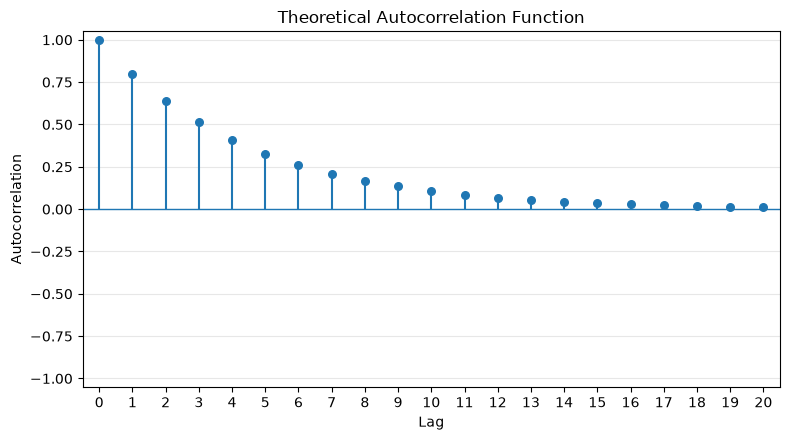

In [19]:
fig, ax = arma.plot_arma_acf(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

### MA(1)

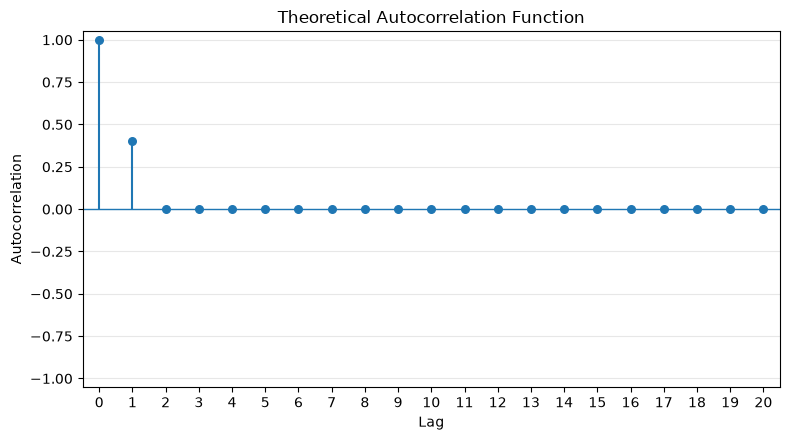

In [20]:
fig, ax = arma.plot_arma_acf(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

## Testing PACF Graph

### AR(1)

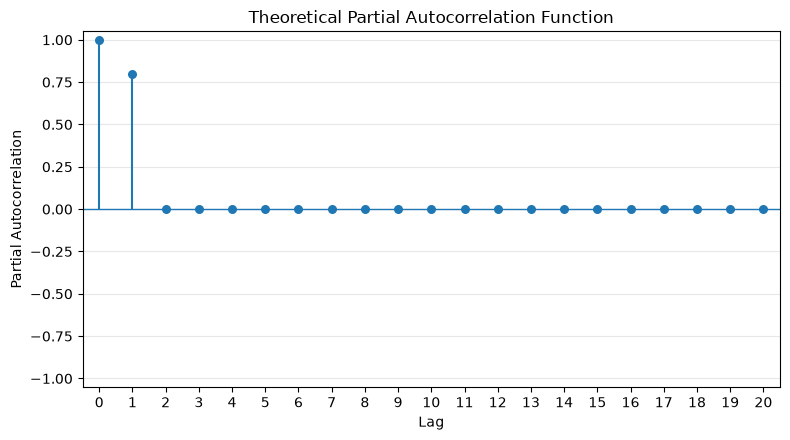

In [21]:
fig, ax = arma.plot_arma_pacf(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

### MA(1)

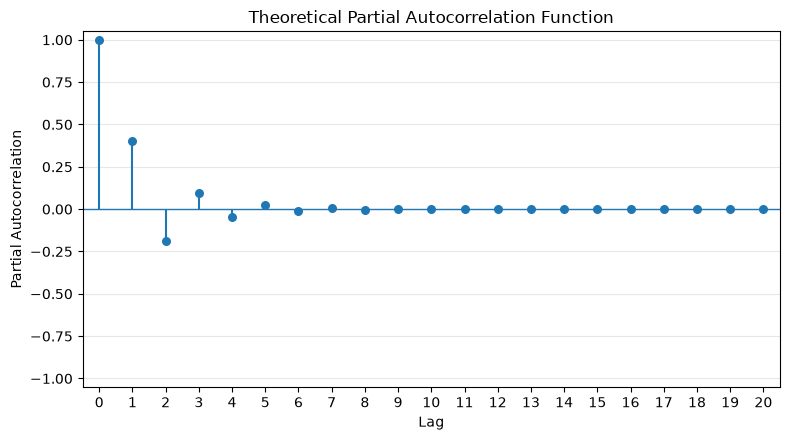

In [22]:
fig, ax = arma.plot_arma_pacf(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

## Testing Combined Graphs

### AR(1)

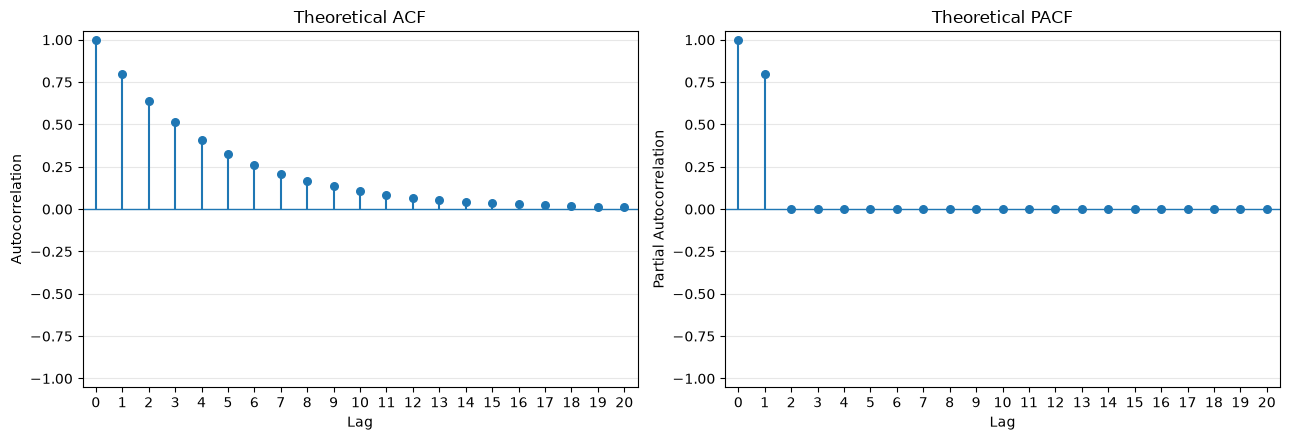

In [23]:
fig, axes = arma.plot_arma_correlations(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

### MA(1)

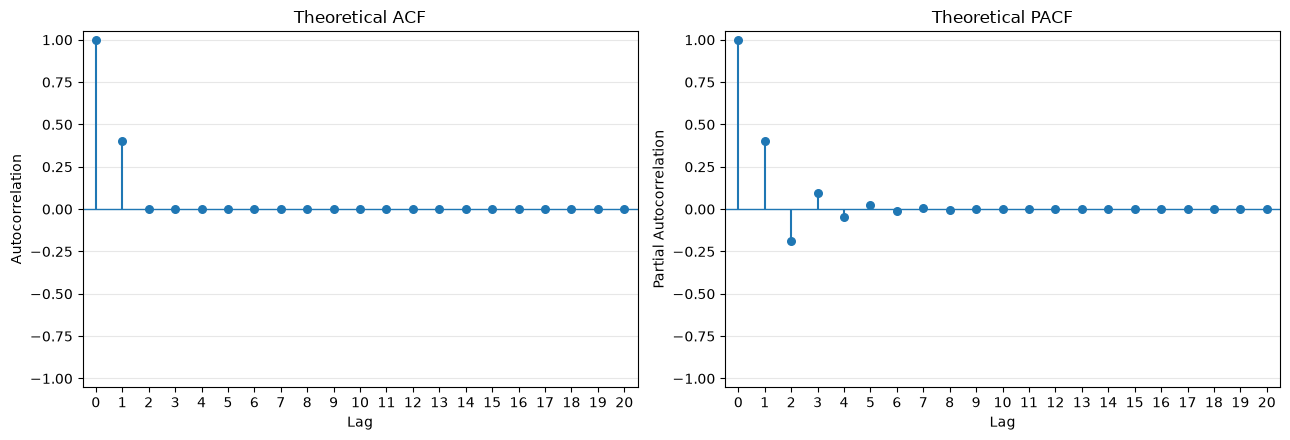

In [24]:
fig, axes = arma.plot_arma_correlations(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

### ARMA(1,1)

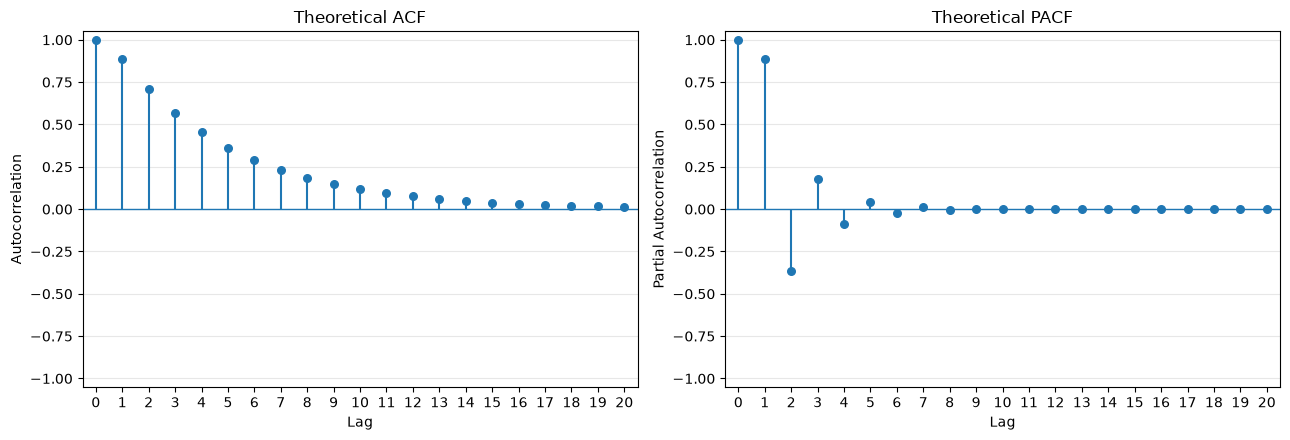

In [25]:
fig, axes = arma.plot_arma_correlations(
    ar=[0.8],
    ma=[0.5],
    n_lags=20,
)

# $\Psi$ Weights

## AR(1)

In [26]:
psi = arma.arma_psi_weights(
    ar=[0.8],
    ma=[],
    n_terms=10,
)

psi

array([1.        , 0.8       , 0.64      , 0.512     , 0.4096    ,
       0.32768   , 0.262144  , 0.2097152 , 0.16777216, 0.13421773])

In [27]:
np.allclose(
    psi,
    0.8 ** np.arange(10)
)

True

## Random Walk

In [28]:
psi_rw = arma.arma_psi_weights(
    ar=[1.0],
    ma=[],
    n_terms=10,
)

psi_rw

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Explosive AR

In [29]:
psi_explosive = arma.arma_psi_weights(
    ar=[1.2],
    ma=[],
    n_terms=10,
)

psi_explosive

array([1.        , 1.2       , 1.44      , 1.728     , 2.0736    ,
       2.48832   , 2.985984  , 3.5831808 , 4.29981696, 5.15978035])

In [30]:
np.allclose(
    psi_explosive,
    1.2 ** np.arange(10)
)

True

## Stable Oscillatory AR(2)

In [31]:
psi_ar2 = arma.arma_psi_weights(
    ar=[1.2, -0.8],
    ma=[],
    n_terms=20,
)

psi_ar2

array([ 1.        ,  1.2       ,  0.64      , -0.192     , -0.7424    ,
       -0.73728   , -0.290816  ,  0.2408448 ,  0.52166656,  0.43332403,
        0.10265559, -0.22347252, -0.35029149, -0.24157178, -0.00965294,
        0.1816739 ,  0.22573103,  0.12553811, -0.02993908, -0.13635739])

## ARMA(1,1)

In [32]:
psi_arma11 = arma.arma_psi_weights(
    ar=[0.8],
    ma=[0.5],
    n_terms=10,
)

psi_arma11

array([1.        , 1.3       , 1.04      , 0.832     , 0.6656    ,
       0.53248   , 0.425984  , 0.3407872 , 0.27262976, 0.21810381])

## stationary-theory functions reject noncausal models

In [33]:
#arma.arma_acf(
#    ar=[1.0],
#    ma=[],
#    n_lags=10,
#)

In [34]:
arma.arma_psi_weights(
    ar=[1.0],
    ma=[],
    n_terms=10,
)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Dynamics

In [35]:
cumulative = np.cumsum(psi_rw)
cumulative

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

# Dynamic Analysis

## Stable AR(1)

In [36]:
# Stable AR(1)
arma.arma_dynamics(
    ar=[0.8],
    ma=[],
    horizon=15,
)

{'psi': array([1.        , 0.8       , 0.64      , 0.512     , 0.4096    ,
        0.32768   , 0.262144  , 0.2097152 , 0.16777216, 0.13421773,
        0.10737418, 0.08589935, 0.06871948, 0.05497558, 0.04398047,
        0.03518437]),
 'cumulative_psi': array([1.        , 1.8       , 2.44      , 2.952     , 3.3616    ,
        3.68928   , 3.951424  , 4.1611392 , 4.32891136, 4.46312909,
        4.57050327, 4.65640262, 4.72512209, 4.78009767, 4.82407814,
        4.85926251]),
 'causal': True,
 'long_run_exists': True,
 'long_run_response': np.float64(5.000000000000001),
 'horizon': 15}

## Random Walk

In [37]:
# Random walk
arma.arma_dynamics(
    ar=[1.0],
    ma=[],
    horizon=15,
)

{'psi': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'cumulative_psi': array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16.]),
 'causal': False,
 'long_run_exists': False,
 'long_run_response': None,
 'horizon': 15}

## Explosive AR(1)

In [38]:
# Explosive AR(1)
arma.arma_dynamics(
    ar=[1.2],
    ma=[],
    horizon=15,
)

{'psi': array([ 1.        ,  1.2       ,  1.44      ,  1.728     ,  2.0736    ,
         2.48832   ,  2.985984  ,  3.5831808 ,  4.29981696,  5.15978035,
         6.19173642,  7.43008371,  8.91610045, 10.69932054, 12.83918465,
        15.40702157]),
 'cumulative_psi': array([ 1.        ,  2.2       ,  3.64      ,  5.368     ,  7.4416    ,
         9.92992   , 12.915904  , 16.4990848 , 20.79890176, 25.95868211,
        32.15041853, 39.58050224, 48.49660269, 59.19592323, 72.03510787,
        87.44212945]),
 'causal': False,
 'long_run_exists': False,
 'long_run_response': None,
 'horizon': 15}

# Dynamics Graphs

## Stable AR(1): monotonic decay

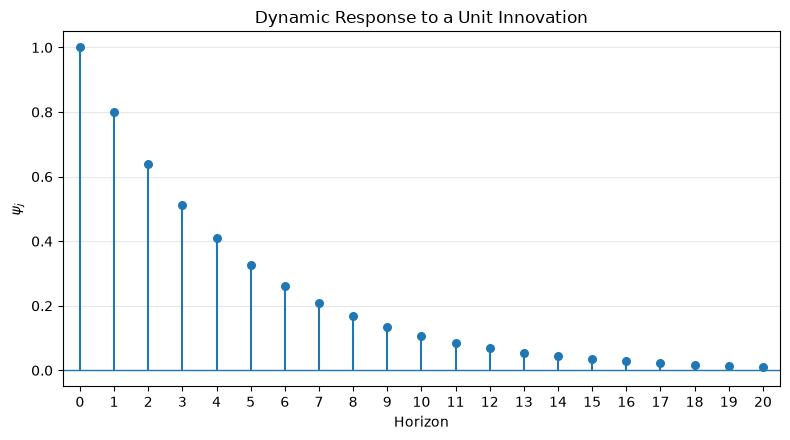

In [39]:
fig, ax = arma.plot_arma_dynamic_response(
    ar=[0.8],
    ma=[],
    horizon=20,
)

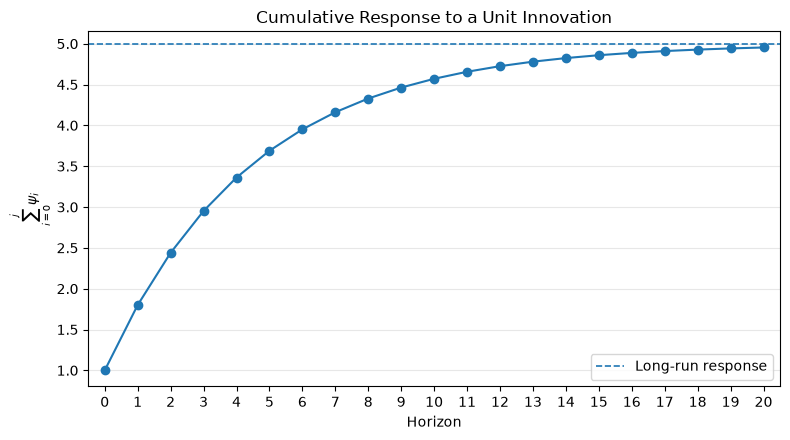

In [40]:
fig, ax = arma.plot_arma_cumulative_response(
    ar=[0.8],
    ma=[],
    horizon=20,
)

## ARMA(1,1): initial amplification

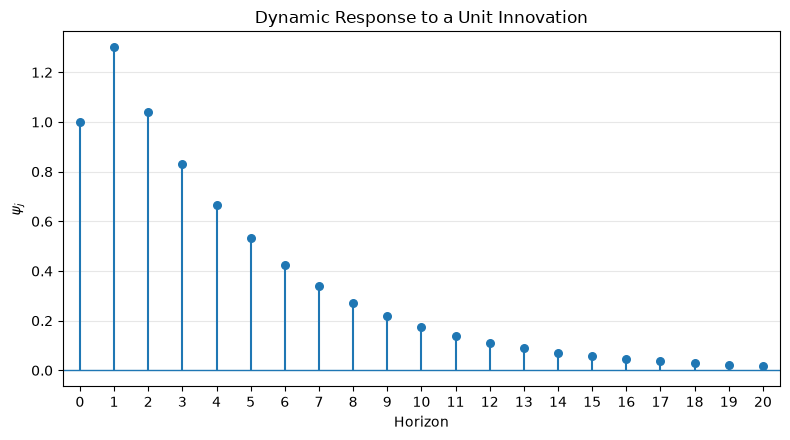

In [41]:
fig, ax = arma.plot_arma_dynamic_response(
    ar=[0.8],
    ma=[0.5],
    horizon=20,
)

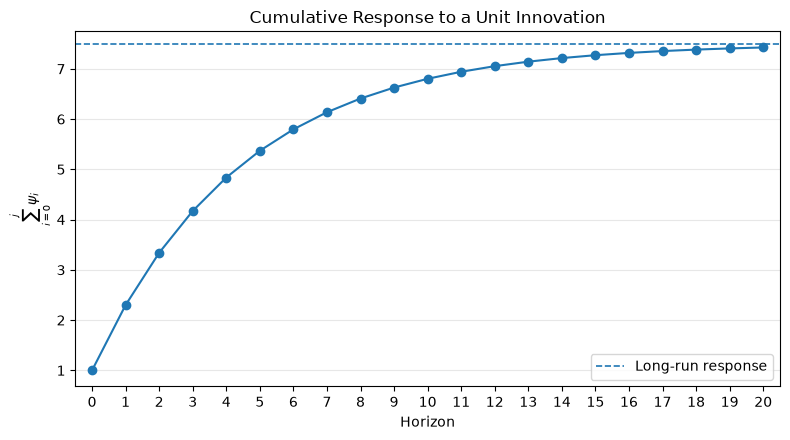

In [42]:
fig, ax = arma.plot_arma_cumulative_response(
    ar=[0.8],
    ma=[0.5],
    horizon=20,
)

## Random walk: permanent response

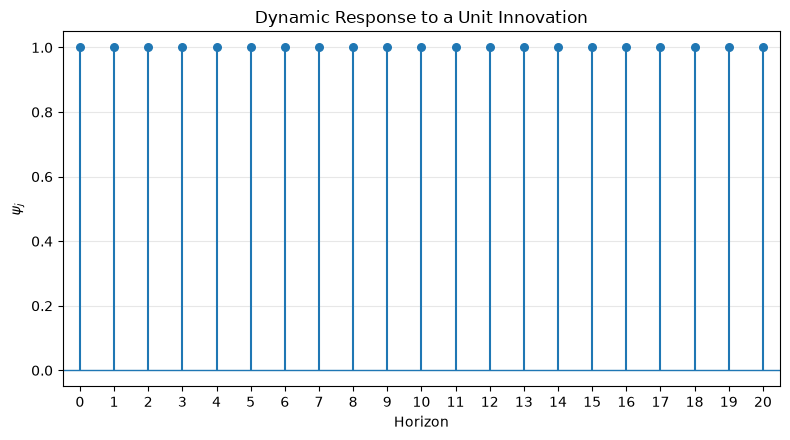

In [43]:
fig, ax = arma.plot_arma_dynamic_response(
    ar=[1.0],
    ma=[],
    horizon=20,
)

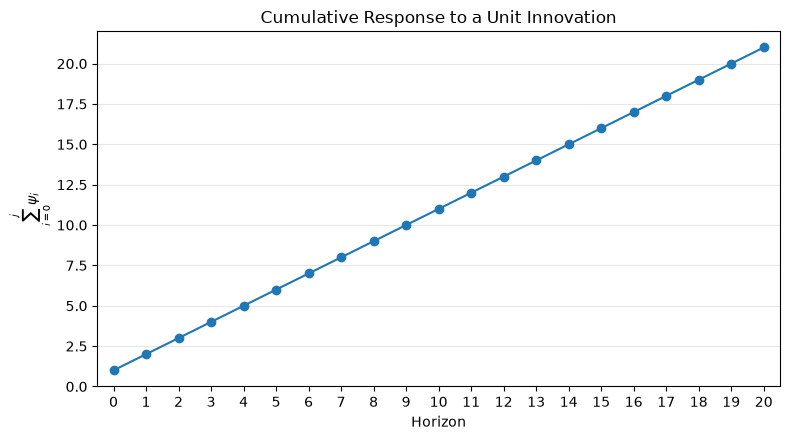

In [44]:
fig, ax = arma.plot_arma_cumulative_response(
    ar=[1.0],
    ma=[],
    horizon=20,
)

## Explosive AR(1)

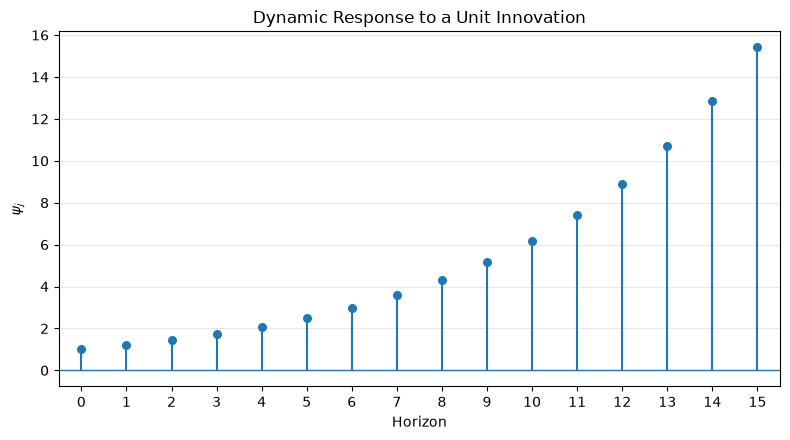

In [45]:
fig, ax = arma.plot_arma_dynamic_response(
    ar=[1.2],
    ma=[],
    horizon=15,
)

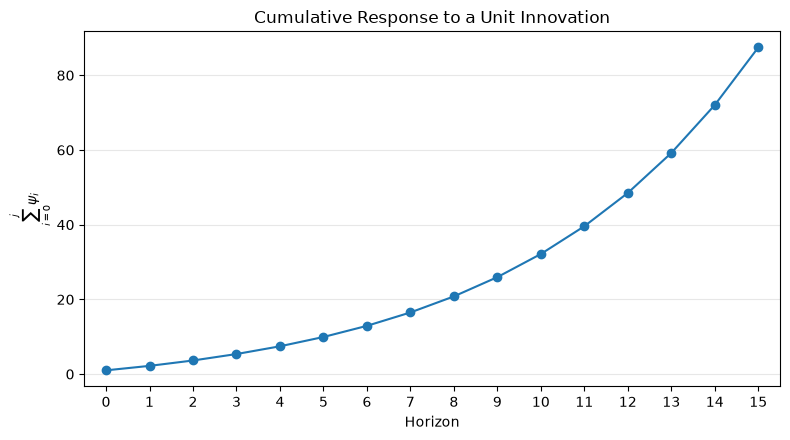

In [46]:
fig, ax = arma.plot_arma_cumulative_response(
    ar=[1.2],
    ma=[],
    horizon=15,
)

## AR(2) Damped Oscillation

In [47]:
ar = [1.2, -0.8]
ma = []

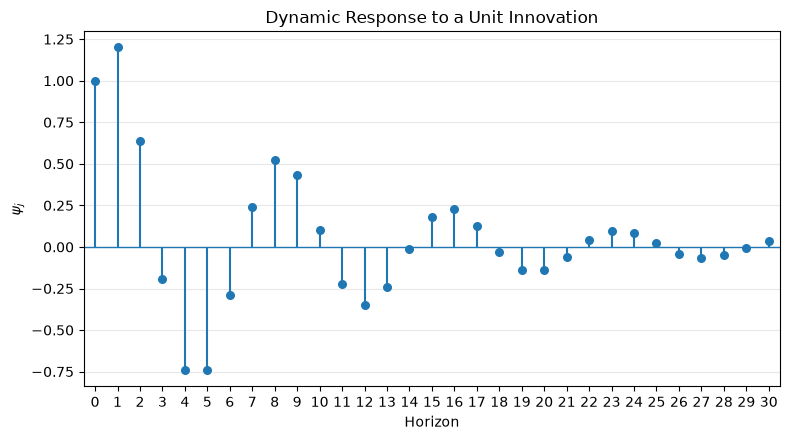

In [48]:
fig, ax = arma.plot_arma_dynamic_response(
    ar=ar,
    ma=ma,
    horizon=30,
)

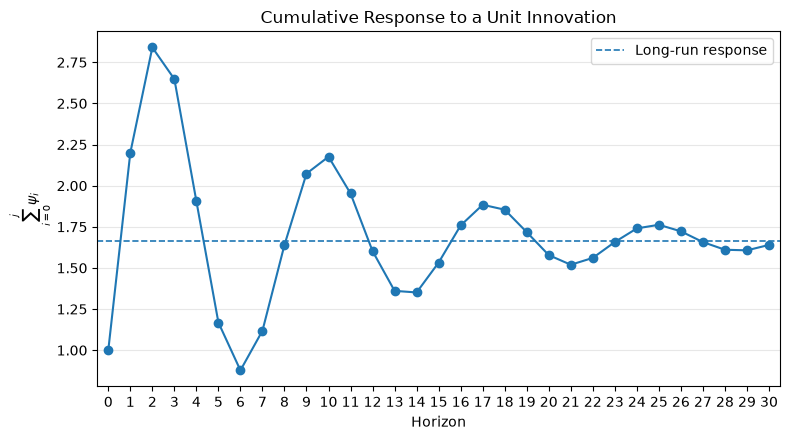

In [49]:
fig, ax = arma.plot_arma_cumulative_response(
    ar=ar,
    ma=ma,
    horizon=30,
)

In [50]:
arma.arma_diagnostics(
    ar=ar,
    ma=ma,
)

{'order': (2, 0),
 'ar': array([ 1.2, -0.8]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1. , -1.2,  0.8]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([0.75+0.8291562j, 0.75-0.8291562j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([0.6-0.66332496j, 0.6+0.66332496j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

In [51]:
ar = [1.2, -0.8]
ma = []

results = arma.arma_dynamics(
    ar=ar,
    ma=ma,
    horizon=30,
)

In [52]:
arma.arma_summary(results)

ARMA Dynamic Analysis
Causal model ............. True
Long-run response ........ 1.666667
Analysis horizon ......... 30

 Horizon        psi_j   Cumulative psi
--------------------------------------
       0       1.0000           1.0000
       1       1.2000           2.2000
       2       0.6400           2.8400
       3      -0.1920           2.6480
       4      -0.7424           1.9056
       5      -0.7373           1.1683
       6      -0.2908           0.8775
       7       0.2408           1.1183
       8       0.5217           1.6400
       9       0.4333           2.0733
      10       0.1027           2.1760
      11      -0.2235           1.9525
      12      -0.3503           1.6022
      13      -0.2416           1.3607
      14      -0.0097           1.3510
      15       0.1817           1.5327
      16       0.2257           1.7584
      17       0.1255           1.8839
      18      -0.0299           1.8540
      19      -0.1364           1.7177
      20      -0.1397

# Inverse Roots

## AR(2)

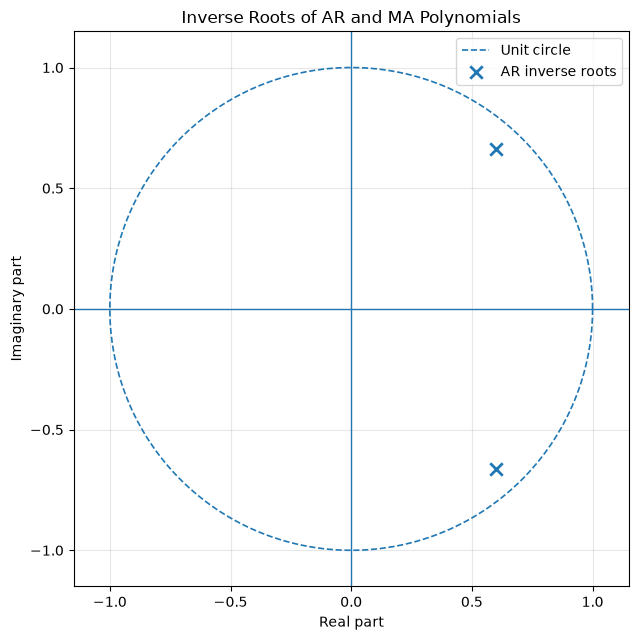

In [53]:
ar = [1.2, -0.8]
ma = []

fig, ax = arma.plot_arma_inverse_roots(
    ar=ar,
    ma=ma,
)

## ARMA(1,1)

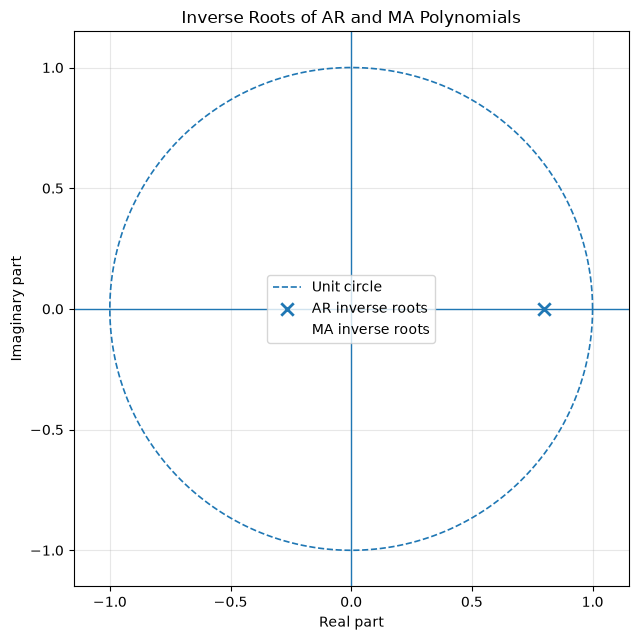

In [54]:
fig, ax = arma.plot_arma_inverse_roots(
    ar=[0.8],
    ma=[0.5],
)

## Common Roots

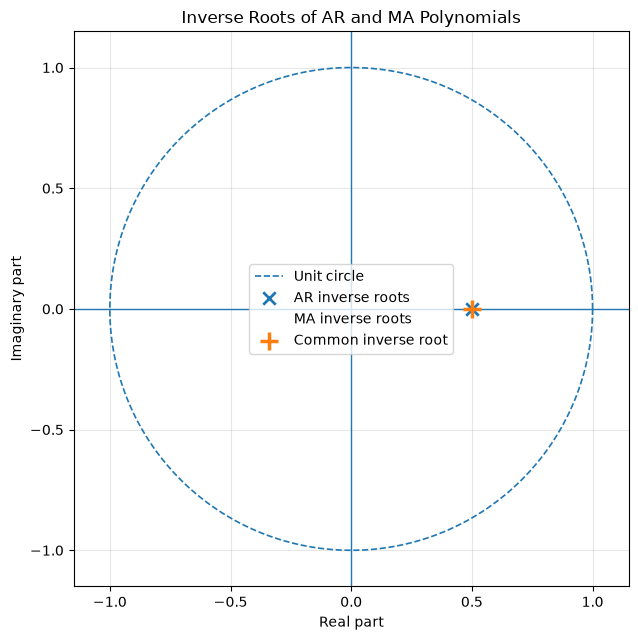

In [55]:
fig, ax = arma.plot_arma_inverse_roots(
    ar=[0.5],
    ma=[-0.5],
)

# Plotly Graphs

## AR(1)

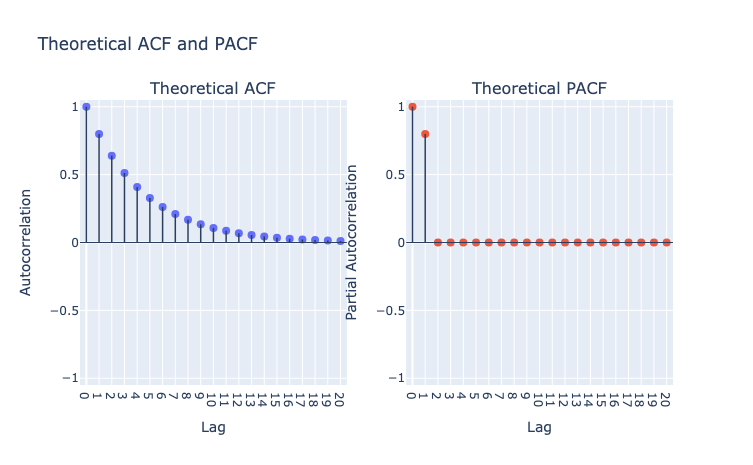

In [56]:
arma.plotly_arma_correlations(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

## MA(1)

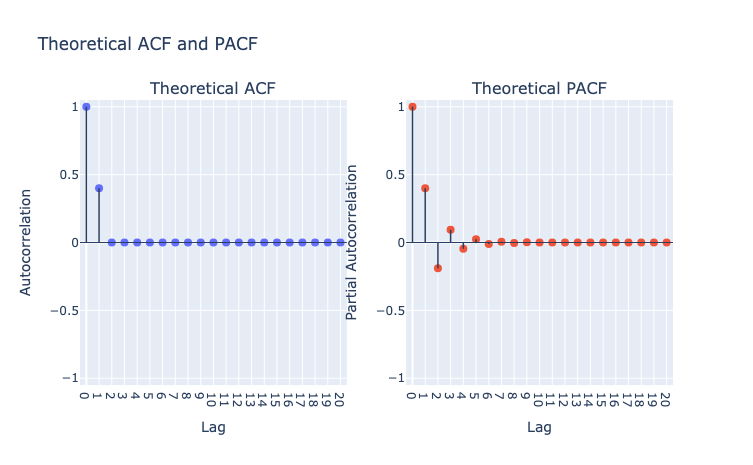

In [57]:
arma.plotly_arma_correlations(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

## ARMA(1,1)

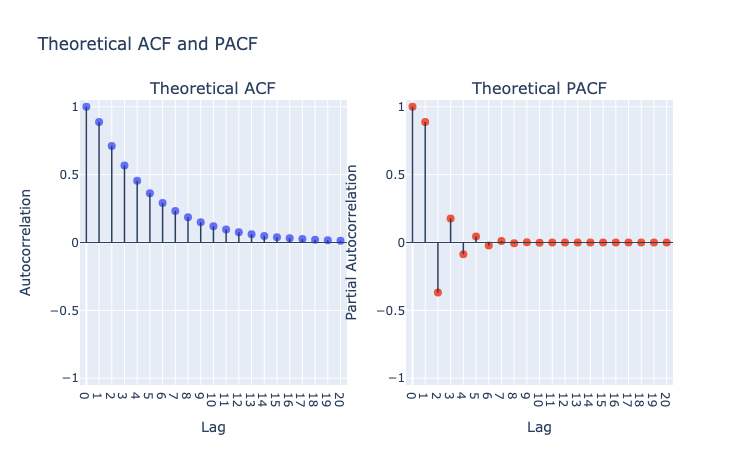

In [58]:
arma.plotly_arma_correlations(
    ar=[0.8],
    ma=[0.5],
    n_lags=20,
)

# Dynamic Response

## ARMA(1,1)

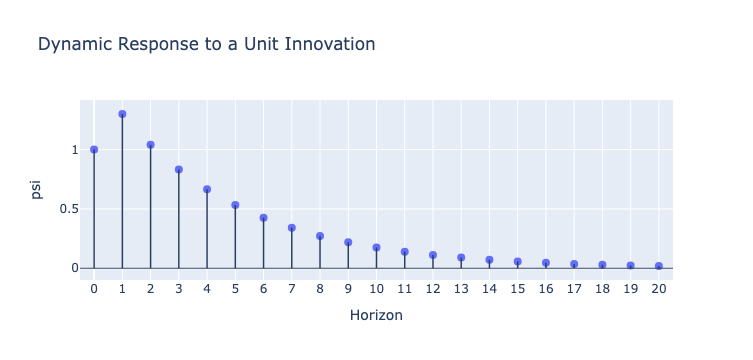

In [59]:
arma.plotly_arma_dynamic_response(
    ar=[0.8],
    ma=[0.5],
    horizon=20,
)

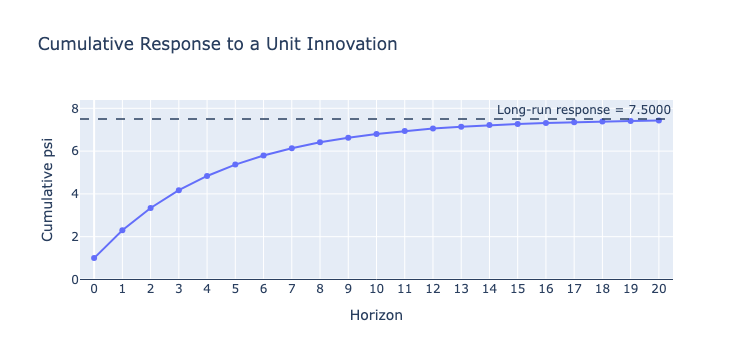

In [60]:
arma.plotly_arma_cumulative_response(
    ar=[0.8],
    ma=[0.5],
    horizon=20,
)

## Random Walk

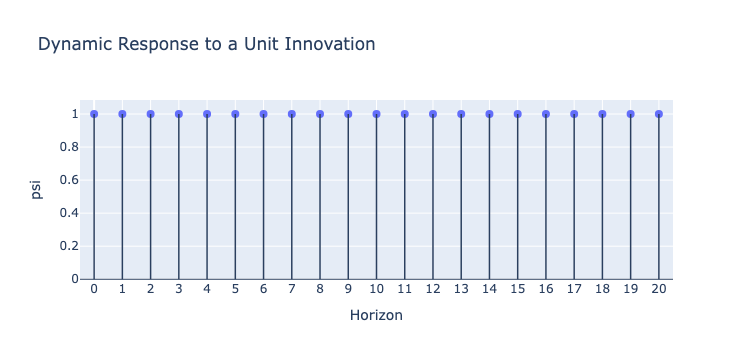

In [61]:
arma.plotly_arma_dynamic_response(
    ar=[1.0],
    ma=[],
    horizon=20,
)



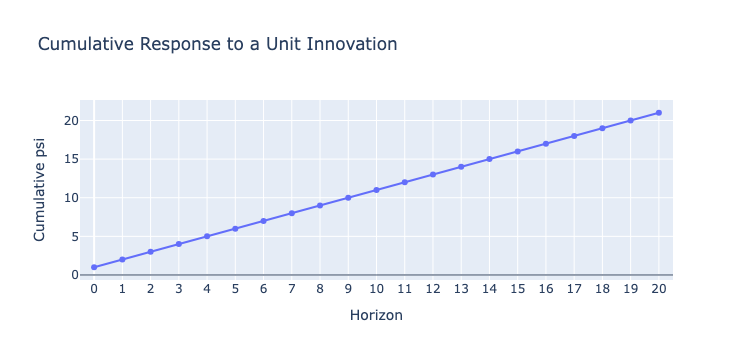

In [62]:
arma.plotly_arma_cumulative_response(
    ar=[1.0],
    ma=[],
    horizon=20,
)

## Explosive AR(1)

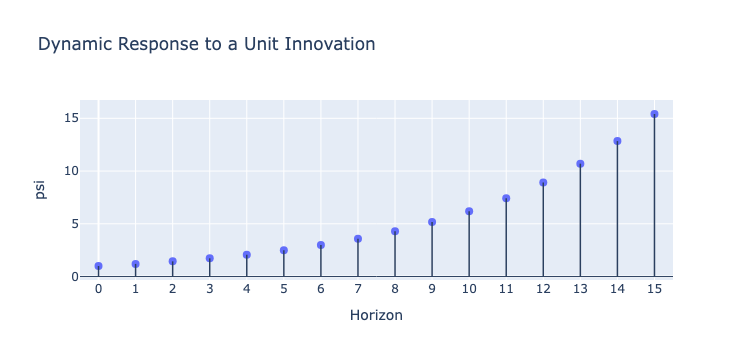

In [63]:
arma.plotly_arma_dynamic_response(
    ar=[1.2],
    ma=[],
    horizon=15,
)

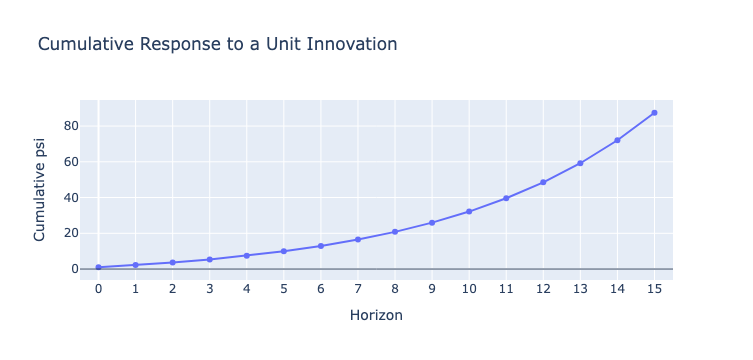

In [64]:
arma.plotly_arma_cumulative_response(
    ar=[1.2],
    ma=[],
    horizon=15,
)

## Oscillatory AR(2)

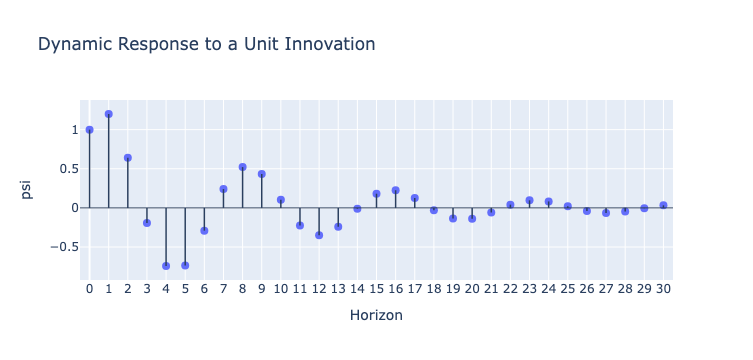

In [65]:
arma.plotly_arma_dynamic_response(
    ar=[1.2, -0.8],
    ma=[],
    horizon=30,
)

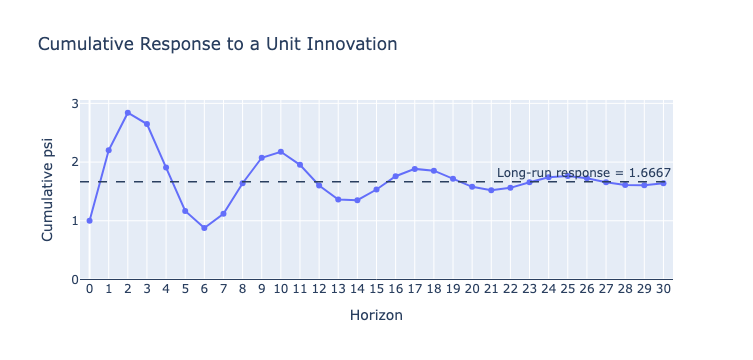

In [66]:
arma.plotly_arma_cumulative_response(
    ar=[1.2, -0.8],
    ma=[],
    horizon=30,
)

# Plotly Inverse Roots

## ARMA(1,1)

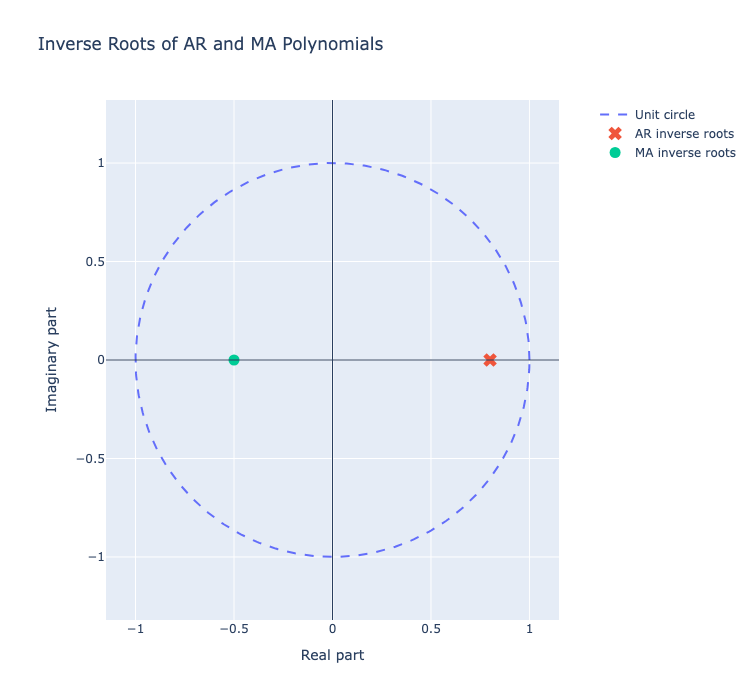

In [67]:
# ARMA(1,1)
arma.plotly_arma_inverse_roots(
    ar=[0.8],
    ma=[0.5],
)

## AR(2)

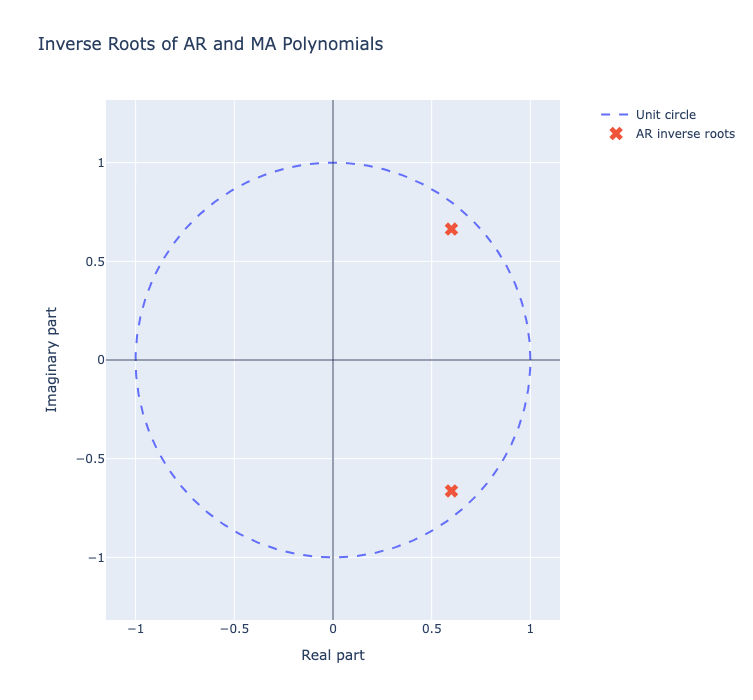

In [68]:
# AR(2) with complex roots
arma.plotly_arma_inverse_roots(
    ar=[1.2, -0.8],
    ma=[],
)

## Common Roots

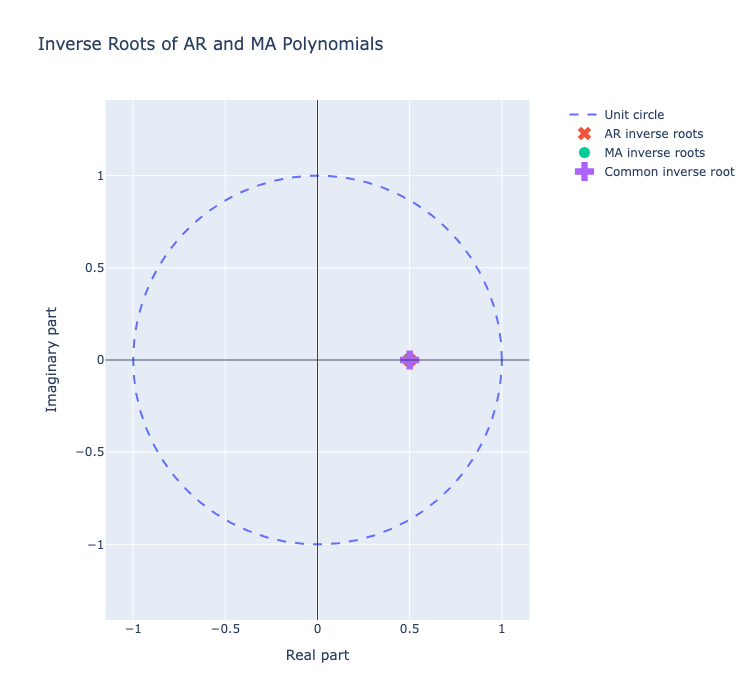

In [69]:
# Common-root case
arma.plotly_arma_inverse_roots(
    ar=[0.5],
    ma=[-0.5],
)